# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Nayla Poetri Kurnia
- **Email:** cdcc200d6x2356@student.devacademy.id
- **ID Dicoding:** CDCC200D6X2356

## Latar Belakang
Dataset ini digunakan untuk menganalisis pola penggunaan sepeda berdasarkan faktor cuaca, musim, dan suhu.

## Tujuan Analisis
- Mengetahui pengaruh suhu terhadap jumlah penyewaan
- Mengidentifikasi pola penggunaan berdasarkan musim
- Melihat tren penggunaan dari waktu ke waktu

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 :  Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda?
- Pertanyaan 2 : Bagaimana pola penyewaan sepeda berdasarkan musim?
- Pertanyaan 3 : Bagaimana tren penyewaan sepeda dari waktu ke waktu dan bagaimana distribusinya?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

Pada tahap ini dilakukan proses pengambilan data dari file CSV yang berisi informasi penyewaan sepeda harian.

In [2]:
df = pd.read_csv("dashboard/data_day.csv")
df["dteday"] = pd.to_datetime(df["dteday"])

In [3]:
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   instant        731 non-null    int64         
 1   dteday         731 non-null    datetime64[ns]
 2   season         731 non-null    object        
 3   yr             731 non-null    int64         
 4   mnth           731 non-null    int64         
 5   holiday        731 non-null    int64         
 6   weekday        731 non-null    int64         
 7   workingday     731 non-null    int64         
 8   weathersit     731 non-null    object        
 9   temp           731 non-null    float64       
 10  atemp          731 non-null    float64       
 11  hum            731 non-null    float64       
 12  windspeed      731 non-null    float64       
 13  casual         731 non-null    int64         
 14  registered     731 non-null    int64         
 15  cnt            731 non-

**Insight:**
- Dataset memuat berbagai fitur yang mencakup informasi waktu, kondisi cuaca, serta jumlah penyewaan sepeda.
- Terdapat dua tipe pengguna, yaitu casual dan registered, yang membentuk total penyewaan `cnt`.
- Variabel seperti season, weathersit, dan workingday menunjukkan bahwa data memiliki informasi kategori terkait kondisi lingkungan dan waktu.
- Data juga mencakup variabel numerik seperti suhu `temp`, kelembaban `hum`, dan kecepatan angin `windspeed` yang dapat digunakan untuk analisis lebih lanjut.

### Assessing Data

Tahap ini dilakukan untuk memahami struktur dataset, tipe data, serta memeriksa adanya missing values dan data duplicate. Hal ini penting untuk memastikan kualitas data sebelum dilakukan analisis lebih lanjut.

In [4]:
# cek struktur data
df.info()

# statistik deskriptif
df.describe()

# cek missing value
df.isnull().sum()

# cek duplicate
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   instant        731 non-null    int64         
 1   dteday         731 non-null    datetime64[ns]
 2   season         731 non-null    object        
 3   yr             731 non-null    int64         
 4   mnth           731 non-null    int64         
 5   holiday        731 non-null    int64         
 6   weekday        731 non-null    int64         
 7   workingday     731 non-null    int64         
 8   weathersit     731 non-null    object        
 9   temp           731 non-null    float64       
 10  atemp          731 non-null    float64       
 11  hum            731 non-null    float64       
 12  windspeed      731 non-null    float64       
 13  casual         731 non-null    int64         
 14  registered     731 non-null    int64         
 15  cnt            731 non-

np.int64(0)

**Insight:**
- Dataset terdiri dari 731 data dengan 18 fitur yang mencakup informasi waktu, kondisi cuaca, serta jumlah penyewaan sepeda, sehingga cukup representatif untuk analisis pola penggunaan.
- Tidak terdapat missing value maupun data duplikat, sehingga kualitas data dapat dianggap baik dan siap digunakan untuk analisis lebih lanjut.
- Sebagian besar variabel bertipe numerik, yang memungkinkan analisis kuantitatif seperti tren dan perbandingan antar variabel.
- Variabel seperti cuaca `weathersit`, suhu `temp`, dan hari kerja `workingday` berpotensi memiliki pengaruh terhadap jumlah penyewaan sepeda.
- Kolom tanggal `dteday` perlu dikonversi ke format datetime agar dapat digunakan dalam analisis berbasis waktu seperti tren bulanan atau harian.

### Cleaning Data

Tahap ini bertujuan untuk memastikan data siap dianalisis dengan:
- Mengubah tipe data tanggal
- Mengubah label kategori agar lebih mudah dipahami

In [5]:
# Mapping kategori
if df["season"].dtype != "object":
    season_map = {
        1: "Spring",
        2: "Summer",
        3: "Fall",
        4: "Winter"
    }
    df["season"] = df["season"].map(season_map)

if df["weathersit"].dtype != "object":
    weather_map = {
        1: "Clear",
        2: "Mist",
        3: "Light Rain/Snow",
        4: "Heavy Rain/Snow"
    }
    df["weathersit"] = df["weathersit"].map(weather_map)

In [6]:
print(df["season"].value_counts())
print(df["weathersit"].value_counts())

season
Fall      188
Summer    184
Spring    181
Winter    178
Name: count, dtype: int64
weathersit
Clear              463
Mist               247
Light Rain/Snow     21
Name: count, dtype: int64


**Insight:**
- Kolom `dteday` telah dikonversi ke format datetime, sehingga memungkinkan analisis berbasis waktu seperti tren bulanan dan harian.
- Variabel kategorikal seperti `season` dan `weathersit` telah diubah menjadi label yang lebih deskriptif, sehingga mempermudah interpretasi hasil visualisasi dan analisis.
- Tidak terdapat perubahan jumlah data selama proses cleaning, menunjukkan bahwa tidak ada data yang hilang atau terhapus.
- Proses cleaning ini meningkatkan keterbacaan dan kualitas dataset, sehingga siap digunakan untuk analisis eksploratif dan pembuatan visualisasi yang lebih informatif.
- Dengan format data yang sudah rapi, analisis selanjutnya dapat difokuskan pada hubungan antar variabel seperti pengaruh cuaca dan musim terhadap jumlah penyewaan sepeda.

## Exploratory Data Analysis (EDA)

Tahap EDA dilakukan untuk memahami karakteristik data dan pola awal penggunaan sepeda, termasuk hubungan antara variabel cuaca, musim, dan waktu terhadap jumlah penyewaan.

In [7]:
df.describe()

,instant,dteday,yr,mnth,holiday,weekday,workingday,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,0.500684,6.519836,0.028728,2.997264,0.683995,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,0.000000,4.000000,0.000000,1.000000,0.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,1.000000,7.000000,0.000000,3.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,1.000000,10.000000,0.000000,5.000000,1.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,1.000000,12.000000,1.000000,6.000000,1.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,0.500342,3.451913,0.167155,2.004787,0.465233,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


### Explore ...

Analisis dilakukan untuk melihat rata-rata penyewaan sepeda berdasarkan musim, kondisi cuaca, serta faktor waktu lainnya guna memahami pola penggunaan.

In [18]:
df[["season","weathersit","cnt"]].head()

,season,weathersit,cnt
0,Spring,Mist,985
1,Spring,Mist,801
2,Spring,Clear,1349
3,Spring,Clear,1562
4,Spring,Clear,1600


In [8]:
# Analisis rata-rata penggunaan berdasarkan musim
season_analysis = df.groupby("season")["cnt"].mean()
season_analysis

season
Fall      5644.303191
Spring    2604.132597
Summer    4992.331522
Winter    4728.162921
Name: cnt, dtype: float64

In [9]:
# Analisis rata-rata penggunaan berdasarkan kondisi cuaca
weather_analysis = df.groupby("weathersit")["cnt"].mean()
weather_analysis

weathersit
Clear              4876.786177
Light Rain/Snow    1803.285714
Mist               4035.862348
Name: cnt, dtype: float64

In [10]:
# Analisis penggunaan berdasarkan hari kerja vs hari libur
workingday_analysis = df.groupby("workingday")["cnt"].mean()
workingday_analysis

workingday
0    4330.168831
1    4584.820000
Name: cnt, dtype: float64

In [11]:
# Analisis penggunaan berdasarkan hari dalam seminggu
weekday_analysis = df.groupby("weekday")["cnt"].mean()
weekday_analysis

weekday
0    4228.828571
1    4338.123810
2    4510.663462
3    4548.538462
4    4667.259615
5    4690.288462
6    4550.542857
Name: cnt, dtype: float64

In [12]:
monthly = df.resample("ME", on="dteday")["cnt"].sum()
monthly.head()

dteday
2011-01-31     38189
2011-02-28     48215
2011-03-31     64045
2011-04-30     94870
2011-05-31    135821
Freq: ME, Name: cnt, dtype: int64

**Insight:**

- Penyewaan sepeda menunjukkan pola musiman yang jelas, dimana musim Fall memiliki rata-rata penyewaan tertinggi. Hal ini mengindikasikan bahwa kondisi lingkungan pada musim tersebut paling optimal untuk aktivitas bersepeda.

- Kondisi cuaca memiliki pengaruh signifikan terhadap jumlah penyewaan. Cuaca cerah meningkatkan aktivitas penyewaan karena memberikan kenyamanan bagi pengguna, sedangkan hujan atau salju menurunkan minat pengguna secara signifikan.

- Faktor kenyamanan lingkungan, seperti suhu dan kondisi cuaca, menjadi penentu utama dalam keputusan pengguna untuk menggunakan sepeda sebagai sarana transportasi maupun aktivitas rekreasi.

- Pola ini menunjukkan bahwa permintaan penyewaan sepeda dapat diprediksi berdasarkan kondisi lingkungan, sehingga dapat dimanfaatkan untuk perencanaan operasional yang lebih efektif.

## Visualization & Explanatory Analysis

Visualisasi digunakan untuk menjawab pertanyaan bisnis yang telah dirumuskan sebelumnya.

### Pertanyaan 1: Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda?

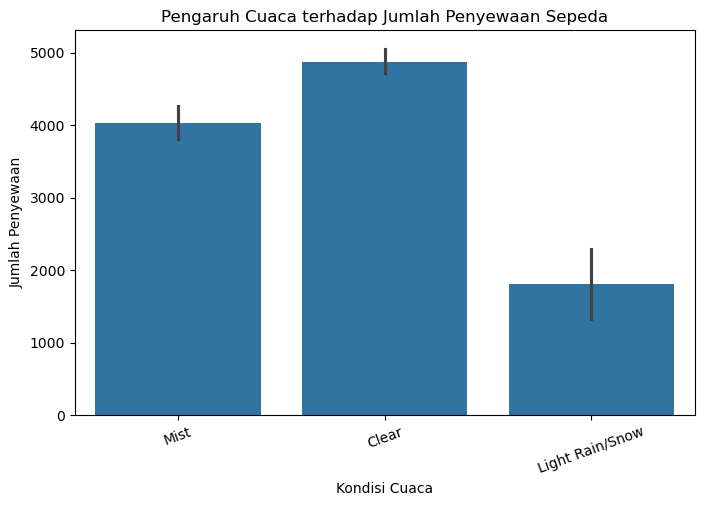

In [13]:
plt.figure(figsize=(8,5))
sns.barplot(x="weathersit", y="cnt", data=df)

plt.title("Pengaruh Cuaca terhadap Jumlah Penyewaan Sepeda")
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Jumlah Penyewaan")
plt.xticks(rotation=20)

plt.show()

**Insight:**

- Kondisi cuaca cerah `Clear` menghasilkan jumlah penyewaan sepeda tertinggi, yang menunjukkan bahwa pengguna lebih cenderung menggunakan sepeda saat kondisi lingkungan mendukung.
-  Cuaca berkabut `Mist` masih menunjukkan tingkat penyewaan yang cukup tinggi, namun lebih rendah dibandingkan cuaca cerah, yang mengindikasikan bahwa penurunan kenyamanan mulai mempengaruhi aktivitas pengguna.
- Kondisi hujan atau salju `Light Rain/Snow` menyebabkan penurunan signifikan pada jumlah penyewaan, menunjukkan bahwa kondisi cuaca buruk menjadi penghambat utama dalam penggunaan sepeda.
- Secara keseluruhan, kondisi cuaca merupakan faktor penting yang mempengaruhi keputusan pengguna dalam menyewa sepeda, sehingga dapat dijadikan dasar dalam perencanaan operasional dan strategi layanan.

### Pertanyaan 2: Bagaimana pola penyewaan sepeda berdasarkan musim?

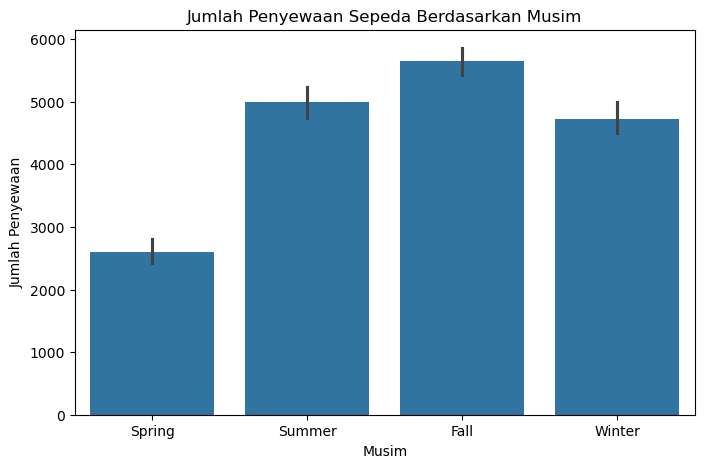

In [14]:
plt.figure(figsize=(8,5))
sns.barplot(x="season", y="cnt", data=df)

plt.title("Jumlah Penyewaan Sepeda Berdasarkan Musim")
plt.xlabel("Musim")
plt.ylabel("Jumlah Penyewaan")

plt.show()

**Insight:**
- Musim `Fall` memiliki jumlah penyewaan sepeda tertinggi dibandingkan musim lainnya, yang menunjukkan bahwa kondisi suhu dan lingkungan pada periode ini paling optimal untuk aktivitas bersepeda.
- Musim `Summer` dan `Winter` juga menunjukkan tingkat penyewaan yang relatif tinggi, mengindikasikan bahwa meskipun kondisi tidak seoptimal Fall, aktivitas bersepeda tetap cukup diminati.
- Musim `Spring` memiliki jumlah penyewaan terendah, yang kemungkinan disebabkan oleh kondisi cuaca yang masih tidak stabil sehingga kurang mendukung aktivitas luar ruangan.
- Secara keseluruhan, terdapat pola musiman yang konsisten dalam penggunaan sepeda, dimana kondisi lingkungan pada musim tertentu sangat mempengaruhi tingkat permintaan penyewaan.
- Pola ini dapat dimanfaatkan untuk perencanaan operasional, seperti penyesuaian jumlah sepeda dan strategi layanan pada musim dengan permintaan tinggi maupun rendah.

## Analisis Lanjutan (Opsional)

### Pertanyaan 3: Bagaimana distribusi tingkat penyewaan sepeda?

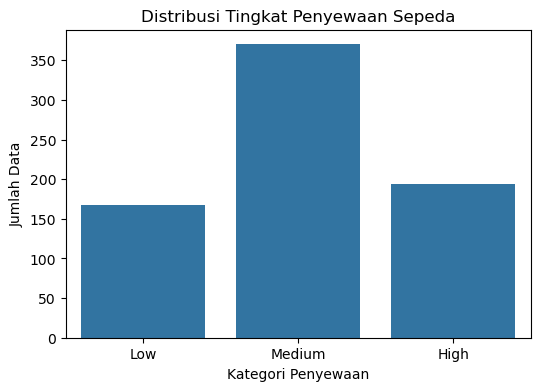

In [15]:
# Binning
df["kategori_sewa"] = pd.cut(
    df["cnt"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

plt.figure(figsize=(6,4))
sns.countplot(x="kategori_sewa", data=df)

plt.title("Distribusi Tingkat Penyewaan Sepeda")
plt.xlabel("Kategori Penyewaan")
plt.ylabel("Jumlah Data")

plt.show()

**Insight:**

- Sebagian besar data berada pada kategori Medium, yang menunjukkan bahwa penggunaan sepeda cenderung stabil.
- Kategori High mengindikasikan adanya lonjakan permintaan pada periode tertentu, sedangkan kategori Low mencerminkan periode dengan aktivitas penyewaan yang rendah.
- Hal ini menunjukkan bahwa distribusi penyewaan tidak merata dan dipengaruhi oleh faktor waktu serta kondisi lingkungan seperti cuaca dan musim.

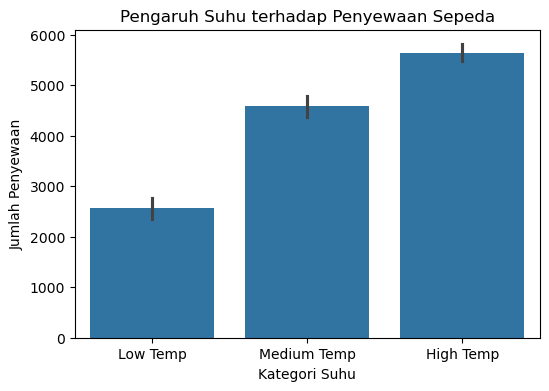

In [16]:
df["temp_group"] = pd.cut(
    df["temp"],
    bins=3,
    labels=["Low Temp", "Medium Temp", "High Temp"]
)

plt.figure(figsize=(6,4))
sns.barplot(x="temp_group", y="cnt", data=df)

plt.title("Pengaruh Suhu terhadap Penyewaan Sepeda")
plt.xlabel("Kategori Suhu")
plt.ylabel("Jumlah Penyewaan")

plt.show()

**Insight:**
- Binning dilakukan menjadi 3 kategori (Low, Medium, High) untuk menyederhanakan interpretasi tingkat penyewaan dan mempermudah analisis distribusi data.
- Penyewaan sepeda meningkat seiring dengan kenaikan suhu.
- Kategori High Temp memiliki jumlah penyewaan tertinggi dibanding kategori lainnya.
- Suhu rendah menunjukkan jumlah penyewaan yang lebih sedikit.
- Hal ini menunjukkan bahwa kenyamanan suhu berpengaruh terhadap minat pengguna dalam bersepeda.

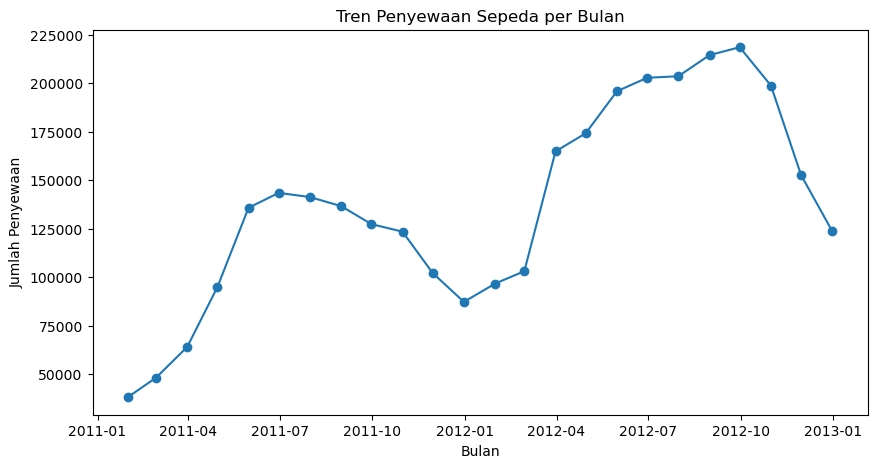

In [17]:
monthly = df.resample("ME", on="dteday")["cnt"].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly.index, monthly.values, marker='o')

plt.title("Tren Penyewaan Sepeda per Bulan")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Penyewaan")

plt.show()

**Insight:**
- Terdapat pola tren yang jelas dalam penyewaan sepeda sepanjang waktu, dimana jumlah penyewaan meningkat secara bertahap dari awal tahun hingga mencapai puncak di pertengahan hingga akhir tahun.
- Puncak penyewaan terjadi pada periode sekitar bulan September hingga Oktober, yang menunjukkan bahwa kondisi lingkungan pada periode tersebut paling mendukung aktivitas bersepeda.
- Setelah mencapai puncak, jumlah penyewaan mengalami penurunan signifikan menuju akhir tahun dan awal tahun berikutnya, yang kemungkinan dipengaruhi oleh perubahan cuaca yang kurang kondusif.
- Pola ini menunjukkan adanya tren musiman yang konsisten setiap tahunnya, dimana permintaan meningkat pada periode tertentu dan menurun pada periode lainnya.
- Tren ini mengindikasikan bahwa waktu `bulan` merupakan faktor penting dalam menentukan tingkat permintaan penyewaan sepeda.
- Informasi ini dapat dimanfaatkan untuk strategi operasional, seperti penyesuaian kapasitas sepeda, pengaturan stok, serta perencanaan promosi pada periode dengan permintaan tinggi maupun rendah.

## Conclusion

1. Pengaruh Cuaca terhadap Penyewaan Sepeda  
Kondisi cuaca memiliki pengaruh signifikan terhadap jumlah penyewaan sepeda. Penyewaan tertinggi terjadi pada kondisi cuaca cerah (Clear), sedangkan kondisi cuaca buruk seperti hujan atau salju menyebabkan penurunan jumlah penyewaan. Hal ini menunjukkan bahwa semakin baik kondisi cuaca, semakin tinggi minat pengguna untuk bersepeda.

2. Pola Penyewaan Berdasarkan Musim  
Penyewaan sepeda menunjukkan pola musiman, dimana musim Fall memiliki jumlah penyewaan tertinggi dan musim Spring terendah. Musim dengan kondisi lingkungan yang lebih nyaman cenderung meningkatkan aktivitas penggunaan sepeda.

3. Distribusi dan Tren Penyewaan Sepeda  
Sebagian besar penyewaan berada pada kategori Medium, menunjukkan bahwa penggunaan sepeda relatif stabil. Namun, terdapat kategori High yang menandakan lonjakan permintaan pada waktu tertentu, serta kategori Low yang menunjukkan periode dengan aktivitas rendah. Selain itu, tren penyewaan menunjukkan pola musiman, dimana jumlah penyewaan meningkat hingga pertengahan tahun dan menurun kembali di akhir tahun. Hal ini menunjukkan bahwa faktor waktu dan kondisi lingkungan berperan dalam variasi tingkat penyewaan sepeda.

Secara keseluruhan, faktor lingkungan seperti cuaca, musim, dan suhu memiliki peran penting dalam menentukan pola dan tingkat penyewaan sepeda, sehingga dapat dijadikan dasar dalam pengambilan keputusan bisnis yang lebih strategis.

## Rekomendasi

- Menambah jumlah sepeda dan ketersediaan layanan pada periode dengan permintaan tinggi seperti Fall dan Summer.
- Mengoptimalkan operasional dan promosi pada kondisi cuaca cerah untuk meningkatkan penggunaan.
- Mengurangi atau menyesuaikan operasional pada kondisi cuaca buruk untuk efisiensi biaya.
- Menggunakan data historis dan tren musiman untuk perencanaan distribusi sepeda yang lebih tepat dan prediktif.